In [24]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = {
    "sp500": "^GSPC",
    "nasdaq": "^IXIC",
    "russell2000": "^RUT",
}

end = pd.Timestamp("2026-04-01")
start = end - pd.DateOffset(years=10)

df = yf.download(
    list(tickers.values()),
    start=start.strftime("%Y-%m-%d"),
    end=(end + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    interval="1d",
    auto_adjust=False,
    progress=True,
    group_by="ticker",
)

df = df.xs("Adj Close", axis=1, level="Price")
df = df.rename(columns={v: k for k, v in tickers.items()})

[*********************100%***********************]  3 of 3 completed


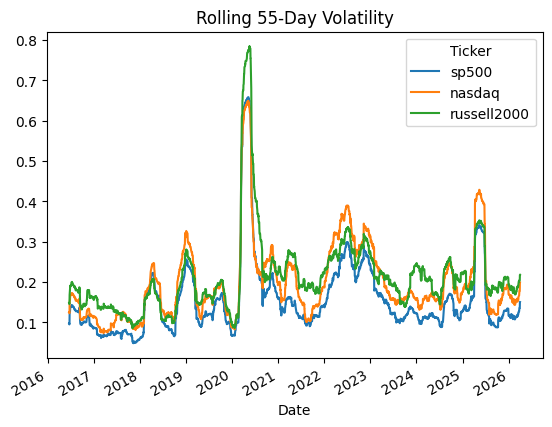

In [25]:
returns = df.pct_change().dropna()

# mean returns
mean_returns = returns.mean()

# annualized volatility
volatility = returns.std() * np.sqrt(252)

# downside deviation
downside_returns = returns[returns < 0]
downside_deviation = downside_returns.std() * np.sqrt(252)

# 1 nd 5 % return quantiles
quantiles = returns.quantile([0.01, 0.05])

# 0.95 and 0.99 CVaR
cvar_95 = returns[returns <= quantiles.loc[0.05]].mean()
cvar_99 = returns[returns <= quantiles.loc[0.01]].mean()

# skewness
skewness = returns.skew()

# kurtosis
kurtosis = returns.kurtosis()

# maximum drawdown
cumulative_returns = (1 + returns).cumprod()
running_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - running_max) / running_max
max_drawdown = drawdown.min()

# rolling 55-day volatility plot
rolling_volatility = returns.rolling(window=55).std() * np.sqrt(252)
rolling_volatility.plot(title="Rolling 55-Day Volatility")

# save plot
plt.savefig("rolling_volatility.png", dpi=300)

# save statistics to csv
stats_df = pd.DataFrame({
    "mean_return":        mean_returns.round(5),
    "volatility":         volatility.round(4),
    "downside_deviation": downside_deviation.round(4),
    "quantile_1%":        quantiles.loc[0.01].round(4),
    "quantile_5%":        quantiles.loc[0.05].round(4),
    "cvar_95":            cvar_95.round(4),
    "cvar_99":            cvar_99.round(4),
    "skewness":           skewness.round(4),
    "kurtosis":           kurtosis.round(4),
    "max_drawdown":       max_drawdown.round(4),
})

stats_df.to_csv("validation_data_statistics.csv")